In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

SyntaxError: invalid syntax (1698291658.py, line 7)

In [4]:
# =========================
# 데이터 경로
# =========================

base_path = r"C:\Users\Admin\hipython\power_peak_project\data"

power_path = base_path + r"\okm_augumented_2021.csv"
weather_path = base_path + r"\OBS_ASOS_TIM_20260317104950.csv"
demand_path = base_path + r"\HOME_전력수급_실시간전력수급.csv"

In [5]:
# =========================
# CSV 불러오기
# =========================

df_power = pd.read_csv(power_path, encoding="utf-8-sig")
df_weather = pd.read_csv(weather_path, encoding="cp949")
df_demand = pd.read_csv(demand_path, encoding="cp949")

print("전력 데이터 shape:", df_power.shape)
print("기상 데이터 shape:", df_weather.shape)
print("수요 데이터 shape:", df_demand.shape)

전력 데이터 shape: (6168, 18)
기상 데이터 shape: (619887, 11)
수요 데이터 shape: (288, 6)


In [ ]:
# =========================
# datetime 생성, Pandas의 표준 시계열 형식인 datetime으로 통일하는 과정
# =========================

# 전력 데이터
df_power["시간"] = df_power["시간"].astype(str).str.zfill(2)

df_power["datetime"] = pd.to_datetime(
    df_power["날짜"].astype(str) + " " + df_power["시간"] + ":00:00",
    format="%Y%m%d %H:%M:%S",
    errors="coerce"
)

# 기상 데이터
df_weather["datetime"] = pd.to_datetime(df_weather["일시"], errors="coerce")

# 수요 데이터
df_demand["datetime"] = pd.to_datetime(df_demand["일시"], errors="coerce")

In [ ]:
# =========================
# 컬럼명 변경. 각기 다른 출처에서 가져온 데이터프레임의 컬럼명(한글, 특수문자 포함)을 분석하기 쉬운 영문 이름으로 표준화
# =========================

df_power = df_power.rename(columns={
    "평균": "power",
    "생산량": "production",
    "기온": "temperature_factory",
    "풍속": "wind_speed_factory",
    "습도": "humidity_factory",
    "강수량": "rainfall_factory",
    "공장인원": "workers"
})

df_weather = df_weather.rename(columns={
    "기온(°C)": "temperature_weather",
    "강수량(mm)": "rainfall_weather",
    "풍속(m/s)": "wind_speed_weather",
    "습도(%)": "humidity_weather",
    "일사(MJ/m2)": "solar"
})

df_demand = df_demand.rename(columns={
    "현재부하(MW)": "demand_mw"
})

In [9]:
# =========================
# 컬럼 선택
# =========================

df_power = df_power[[
    "datetime","power","production","workers",
    "temperature_factory","humidity_factory",
    "wind_speed_factory","rainfall_factory"
]]

df_weather = df_weather[[
    "datetime","temperature_weather",
    "humidity_weather","wind_speed_weather",
    "rainfall_weather","solar"
]]

df_demand = df_demand[[
    "datetime","demand_mw"
]]

In [ ]:
# =========================
# 시간 단위 정리, 전력 데이터는 15분 단위인데 기상 데이터는 1시간 단위라면 서로 비교가 불가능하기 때문에, 이를 1시간 단위로 표준화하는 과정
# =========================

df_power["datetime"] = df_power["datetime"].dt.floor("h")
df_weather["datetime"] = df_weather["datetime"].dt.floor("h")
df_demand["datetime"] = df_demand["datetime"].dt.floor("h")

df_demand = df_demand.groupby("datetime",as_index=False)["demand_mw"].mean()

In [11]:
# =========================
# 데이터 merge
# =========================

df = pd.merge(df_power, df_weather, on="datetime", how="left")
df = pd.merge(df, df_demand, on="datetime", how="left")

print("merge 완료:", df.shape)

merge 완료: (581087, 14)


In [ ]:
# =========================
# 최종 변수 생성, 데이터 소스 보완. 공장 센서 값이 있으면 → 공장 데이터 사용. 공장 센서 값이 없으면 → 기상청 데이터 사용
# =========================

df["temperature"] = df["temperature_factory"].fillna(df["temperature_weather"])
df["humidity"] = df["humidity_factory"].fillna(df["humidity_weather"])
df["wind_speed"] = df["wind_speed_factory"].fillna(df["wind_speed_weather"])
df["rainfall"] = df["rainfall_factory"].fillna(df["rainfall_weather"])

In [13]:
# =========================
# 결측치 처리
# =========================

df = df.sort_values("datetime").reset_index(drop=True)

num_cols = df.select_dtypes(include=[np.number]).columns

df[num_cols] = df[num_cols].interpolate()
df[num_cols] = df[num_cols].ffill().bfill()

print(df.isnull().sum())

datetime               48
power                   0
production              0
workers                 0
temperature_factory     0
humidity_factory        0
wind_speed_factory      0
rainfall_factory        0
temperature_weather     0
humidity_weather        0
wind_speed_weather      0
rainfall_weather        0
solar                   0
demand_mw               0
temperature             0
humidity                0
wind_speed              0
rainfall                0
dtype: int64


In [ ]:
# =========================
# 최종 데이터
#"우리 공장이 가동 중일 때(내부), 날씨가 이러하면(외부), 전체 전력 상황(계통)에 비추어 볼 때 전력을 얼마나 쓸 것인가?"
# =========================

df_final = df[[
    "datetime","power","production","workers",
    "temperature","humidity","wind_speed","rainfall",
    "solar","demand_mw"
]]

df_final.to_csv(base_path + r"\final_dataset.csv",index=False,encoding="utf-8-sig")

print("final_dataset.csv 저장 완료")

final_dataset.csv 저장 완료


In [16]:
# =========================
# 언제 전기를 많이 쓰는가? 냉난방 힌트로 날씨가 얼마나 영향을 주는가? 1시간전, 24시간 전 전력. 최근 3시간이나 하루 동안 전반적으로 전기를 많이 쓰는 추세. 빈칸채우기
# =========================
df = df_final.copy()

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month

df["CDD"] = (df["temperature"]-18).clip(lower=0)
df["HDD"] = (18-df["temperature"]).clip(lower=0)

df["lag_power_1"] = df["power"].shift(1)
df["lag_power_24"] = df["power"].shift(24)

df["rolling_mean_3"] = df["power"].rolling(3).mean()
df["rolling_mean_24"] = df["power"].rolling(24).mean()

df = df.ffill().bfill()

In [ ]:
# =========================
# X와 y값 지정. y 타겟은 전력량. 여러 features들을 X값으로 하여 y 전력량을 예측한다. 
# shuffle=False과거-> 미래 순 유지. 
# =========================
features = [
    "production","workers",
    "temperature","humidity","wind_speed","rainfall",
    "solar","demand_mw",
    "hour","weekday","month",
    "CDD","HDD",
    "lag_power_1","lag_power_24",
    "rolling_mean_3","rolling_mean_24"
]

X = df[features]
y = df["power"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train,y_train)

print("Train R2:",model.score(X_train,y_train))
print("Test R2:",model.score(X_test,y_test))

Train R2: 0.9999296069145203
Test R2: 0.9976896047592163


In [18]:
# =========================
# Feature Importance 확인
# =========================

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=False
)

print(feature_importance_df)

            feature  importance
15   rolling_mean_3    0.771982
13      lag_power_1    0.114747
16  rolling_mean_24    0.109528
14     lag_power_24    0.001234
8              hour    0.001086
9           weekday    0.000313
1           workers    0.000243
6             solar    0.000212
0        production    0.000169
3          humidity    0.000129
5          rainfall    0.000111
2       temperature    0.000079
4        wind_speed    0.000066
11              CDD    0.000032
7         demand_mw    0.000027
10            month    0.000027
12              HDD    0.000015


결과 설명: 이 공장은 날씨보다 공장 운영 패턴이 전력을 결정한다.
rolling_mean_3 (77%) 최근 3시간 평균 전력
lag_power_1 (11%) 1시간 전 전력
rolling_mean_24 (11%) 지난 24시간 평균

In [19]:
# =========================
# Features 수정
# =========================
df = df_final.copy()

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month

df["CDD"] = (df["temperature"]-18).clip(lower=0)
df["HDD"] = (18-df["temperature"]).clip(lower=0)

df["lag_power_1"] = df["power"].shift(1)
df["lag_power_24"] = df["power"].shift(24)

df["rolling_mean_3"] = df["power"].shift(1).rolling(3).mean()
df["rolling_mean_24"] = df["power"].shift(1).rolling(24).mean()

df = df.ffill().bfill()



In [20]:
# =========================
# 바뀐값 다시
# =========================
features = [
    "production","workers",
    "temperature","humidity","wind_speed","rainfall",
    "solar","demand_mw",
    "hour","weekday","month",
    "CDD","HDD",
    "lag_power_1","lag_power_24",
    "rolling_mean_3","rolling_mean_24"
]

X = df[features]
y = df["power"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train,y_train)

print("Train R2:",model.score(X_train,y_train))
print("Test R2:",model.score(X_test,y_test))

Train R2: 0.9994781613349915
Test R2: 0.9951108694076538


In [21]:
# =========================
# Feature Importance 확인
# =========================

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=False
)

print(feature_importance_df)

            feature  importance
13      lag_power_1    0.613021
15   rolling_mean_3    0.229229
16  rolling_mean_24    0.151325
8              hour    0.001696
14     lag_power_24    0.001626
9           weekday    0.000573
1           workers    0.000556
0        production    0.000380
2       temperature    0.000282
6             solar    0.000267
3          humidity    0.000265
11              CDD    0.000203
10            month    0.000202
4        wind_speed    0.000118
12              HDD    0.000109
5          rainfall    0.000083
7         demand_mw    0.000064


In [22]:
# =========================
# 전력 피크 예측 프로젝트에서 실제로 사용하는 Feature Engineering 20개 중 csv파일로 추출가능한 부분 추가해서 다시
# =========================

# =========================
# 데이터 불러오기
# =========================

base_path = r"C:\Users\Admin\hipython\power_peak_project\data"

df = pd.read_csv(base_path + r"\final_dataset.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values("datetime").reset_index(drop=True)


In [23]:
# =========================
# 시간 Feature
# =========================

df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday
df["month"] = df["datetime"].dt.month
df["dayofyear"] = df["datetime"].dt.dayofyear

# 주말 여부
df["is_weekend"] = (df["weekday"] >= 5).astype(int)

In [28]:
import holidays

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

In [30]:
import holidays

kr_holidays = holidays.KR(years=[2021])

print(list(kr_holidays.items())[:5])

[(datetime.date(2021, 1, 1), '신정연휴'), (datetime.date(2021, 2, 12), '설날'), (datetime.date(2021, 2, 11), '설날 전날'), (datetime.date(2021, 2, 13), '설날 다음날'), (datetime.date(2021, 3, 1), '삼일절')]


In [31]:
# =========================
# 피크 시간 Feature
# =========================

df["is_peak_hour"] = df["hour"].isin([13,14,15,16]).astype(int)

In [32]:
# =========================
# 근무 시간 Feature
# =========================

df["is_work_hour"] = df["hour"].between(9,18).astype(int)

In [33]:
# =========================
# 온도 × 시간
# =========================

df["temp_hour_interaction"] = df["temperature"] * df["hour"]

In [34]:
# =========================
# 온도 제곱
# =========================

df["temperature_sq"] = df["temperature"] ** 2

In [35]:
# =========================
# 하루 평균 전력
# =========================

df["daily_mean_power"] = df["power"].shift(1).rolling(24).mean()

In [36]:
df = df.ffill().bfill()

In [37]:
df.to_csv(base_path + r"\final_dataset_features_v2.csv", index=False)

print("추가 Feature 생성 완료")
print(df.head())

추가 Feature 생성 완료
             datetime  power  production  workers  temperature  humidity  \
0 2021-01-01 00:00:00     61           0      0.0         -3.2        71   
1 2021-01-01 01:00:00    105           0      0.0         -4.5        77   
2 2021-01-01 01:00:00    105           0      0.0         -4.5        77   
3 2021-01-01 01:00:00    105           0      0.0         -4.5        77   
4 2021-01-01 01:00:00    105           0      0.0         -4.5        77   

   wind_speed  rainfall  solar     demand_mw  hour  weekday  month  dayofyear  \
0         2.4       0.0   0.01  65118.333333   0.0      4.0    1.0        1.0   
1         1.5       0.0   0.01  62736.833333   1.0      4.0    1.0        1.0   
2         1.5       0.0   0.01  62736.833333   1.0      4.0    1.0        1.0   
3         1.5       0.0   0.01  62736.833333   1.0      4.0    1.0        1.0   
4         1.5       0.0   0.01  62736.833333   1.0      4.0    1.0        1.0   

   is_weekend  is_peak_hour  is_work_ho

In [38]:
features = [
    "production",
    "workers",
    "temperature",
    "humidity",
    "wind_speed",
    "rainfall",
    "solar",
    "demand_mw",

    "hour",
    "weekday",
    "month",
    "dayofyear",
    "holiday",
    "is_weekend",

    "lag_power_1",
    "lag_power_2",
    "lag_power_3",
    "lag_power_24",

    "rolling_mean_3",
    "rolling_mean_24",

    "CDD",
    "HDD",

    "is_peak_hour",
    "is_work_hour",
    "temp_hour_interaction",
    "temperature_sq",
    "daily_mean_power"
]

In [39]:
df.to_csv(base_path + r"\final_dataset_features_v2.csv", index=False)

In [40]:
# =========================
# 학습 데이터 준비
# =========================

df_model = pd.read_csv(base_path + r"\final_dataset_features_v2.csv")
df_model["datetime"] = pd.to_datetime(df_model["datetime"])

features = [
    "production",
    "workers",
    "temperature",
    "humidity",
    "wind_speed",
    "rainfall",
    "solar",
    "demand_mw",
    "hour",
    "weekday",
    "month",
    "dayofyear",
    "holiday",
    "is_weekend",
    "CDD",
    "HDD",
    "lag_power_1",
    "lag_power_2",
    "lag_power_3",
    "lag_power_24",
    "lag_power_48",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_mean_24",
    "rolling_std_3",
    "rolling_std_24",
    "power_diff_1",
    "temp_diff_1",
    "temp_x_hour",
    "is_peak_hour",
    "is_work_hour",
    "temp_hour_interaction",
    "temperature_sq",
    "daily_mean_power"
]

# 실제 존재하는 컬럼만 선택
features = [col for col in features if col in df_model.columns]

target = "power"

X = df_model[features]
y = df_model[target]

# 시계열 데이터라 shuffle=False
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("학습 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

학습 데이터 크기: (464869, 18)
테스트 데이터 크기: (116218, 18)


In [41]:
# =========================
# XGBoost 모델 학습
# =========================

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.9963299036026001
Test R2: 0.9831116199493408


In [42]:
# =========================
# 예측
# =========================

df_model["predicted_power"] = model.predict(X)

print(df_model[["datetime", "power", "predicted_power"]].head())

             datetime  power  predicted_power
0 2021-01-01 00:00:00     61        67.831398
1 2021-01-01 01:00:00    105       103.800575
2 2021-01-01 01:00:00    105       103.800575
3 2021-01-01 01:00:00    105       103.800575
4 2021-01-01 01:00:00    105       103.800575


In [43]:
# =========================
# Feature Importance 확인
# =========================

importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    "importance", ascending=False
)

print(feature_importance_df)

                  feature  importance
17       daily_mean_power    0.443205
0              production    0.152940
12             is_weekend    0.108617
14           is_work_hour    0.067138
6                   solar    0.054082
10                  month    0.034093
11              dayofyear    0.030778
8                    hour    0.023773
9                 weekday    0.020875
13           is_peak_hour    0.016915
1                 workers    0.016838
5                rainfall    0.007674
3                humidity    0.007158
2             temperature    0.005180
4              wind_speed    0.003695
16         temperature_sq    0.003469
15  temp_hour_interaction    0.002803
7               demand_mw    0.000768


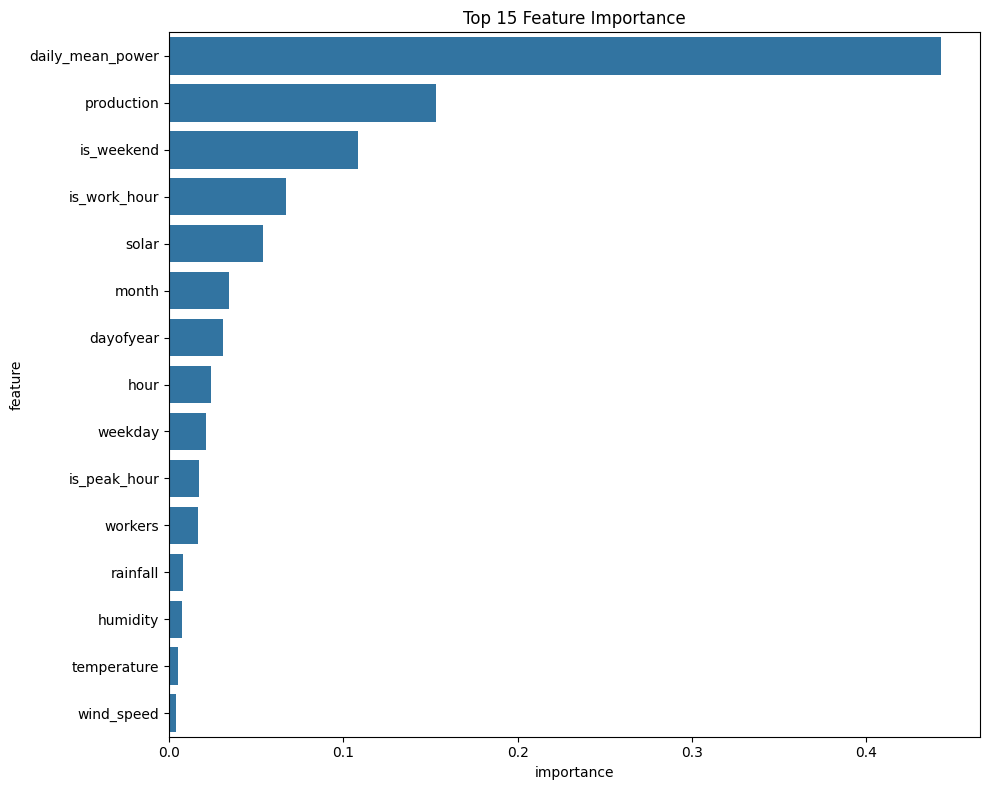

In [44]:
# =========================
# Feature Importance 시각화
# =========================

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

In [45]:
# =========================
# 피크 탐지
# =========================

peak_idx = df_model["predicted_power"].idxmax()
peak_time = df_model.loc[peak_idx, "datetime"]
peak_power = df_model.loc[peak_idx, "predicted_power"]

print("예측 피크 시점:", peak_time)
print("예측 피크 전력:", peak_power)

예측 피크 시점: 2021-07-26 08:00:00
예측 피크 전력: 219.20586


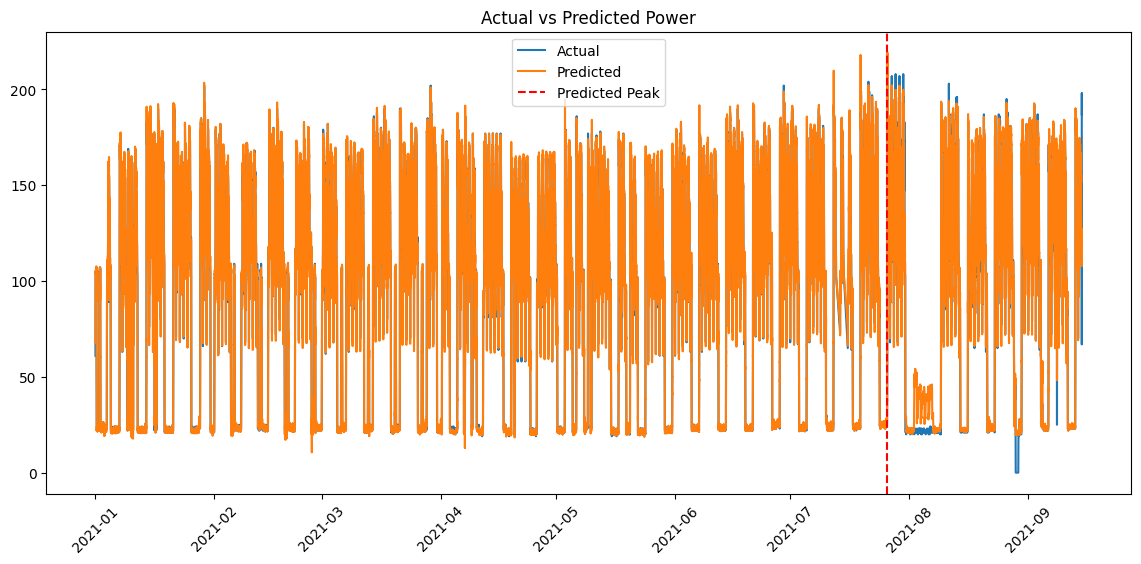

In [46]:
# =========================
# 실제 vs 예측 그래프
# =========================

plt.figure(figsize=(14,6))

plt.plot(df_model["datetime"], df_model["power"], label="Actual")
plt.plot(df_model["datetime"], df_model["predicted_power"], label="Predicted")

plt.axvline(peak_time, color="red", linestyle="--", label="Predicted Peak")

plt.legend()
plt.title("Actual vs Predicted Power")

plt.xticks(rotation=45)

plt.show()

In [47]:
# =========================
# 최대 수요 전력
# =========================

max_power = df_model["predicted_power"].max()

print("예측 최대 수요 전력:", max_power)

예측 최대 수요 전력: 219.20586


In [48]:
# =========================
# 기본요금 계산
# =========================

rate_per_kw = 8320   # 예시 단가

basic_charge = max_power * rate_per_kw

print("기본요금:", round(basic_charge), "원")

기본요금: 1823793 원


In [49]:
# =========================
# DR 시뮬레이션
# =========================

reduction_ratio = 0.1

reduced_power = max_power * reduction_ratio

new_peak = max_power - reduced_power

print("감축 전 피크:", max_power)
print("감축량:", reduced_power)
print("감축 후 피크:", new_peak)

감축 전 피크: 219.20586
감축량: 21.920586
감축 후 피크: 197.28528


In [50]:
# =========================
# 절감 요금
# =========================

saved_basic_charge = reduced_power * rate_per_kw

print("절감 기본요금:", round(saved_basic_charge), "원")

절감 기본요금: 182379 원


In [51]:
# =========================
# DR 수익
# =========================

dr_price = 100

dr_revenue = reduced_power * dr_price

print("DR 수익:", round(dr_revenue), "원")

DR 수익: 2192 원


In [ ]:
# =========================
# 총 절감 효과 전기요금 절감+DR 보상
# =========================

total_profit = saved_basic_charge + dr_revenue

print("총 경제 효과:", round(total_profit), "원")

총 경제 효과: 184571 원


In [53]:
# =========================
# DR 참여 순이익 계산
# =========================

# 1. 예측 피크값
peak_before = df_model["predicted_power"].max()

# 2. DR 참여 가정
reduction_ratio = 0.10   # 10% 감축
peak_after = peak_before * (1 - reduction_ratio)
reduced_amount = peak_before - peak_after

# 3. 기본요금 단가, DR 보상 단가
rate_per_kw = 8320       # 예시
dr_price = 100           # 예시

# 4. DR 미참여 vs 참여 비교
basic_charge_before = peak_before * rate_per_kw
basic_charge_after = peak_after * rate_per_kw

saved_basic_charge = basic_charge_before - basic_charge_after
dr_revenue = reduced_amount * dr_price

# 5. 최종 순이익
dr_net_profit = saved_basic_charge + dr_revenue

# 6. 출력
print("===== DR 참여 효과 분석 =====")
print("DR 미참여 시 예측 피크전력:", round(peak_before, 2))
print("DR 참여 시 예측 피크전력:", round(peak_after, 2))
print("피크 감축량:", round(reduced_amount, 2))
print("기본요금 절감액:", round(saved_basic_charge), "원")
print("DR 보상금:", round(dr_revenue), "원")
print("DR 참여 순이익:", round(dr_net_profit), "원")

===== DR 참여 효과 분석 =====
DR 미참여 시 예측 피크전력: 219.21
DR 참여 시 예측 피크전력: 197.29
피크 감축량: 21.92
기본요금 절감액: 182379 원
DR 보상금: 2192 원
DR 참여 순이익: 184571 원


In [54]:
# =========================
# DR 미참여 손실 계산
# =========================

# DR 미참여 비용
basic_charge_no_dr = peak_before * rate_per_kw

# DR 참여 비용
basic_charge_with_dr = peak_after * rate_per_kw

# DR 참여 시 절감되는 기본요금
saved_basic_charge = basic_charge_no_dr - basic_charge_with_dr

# DR 보상
dr_revenue = reduced_amount * dr_price

# DR 참여 순이익
dr_profit = saved_basic_charge + dr_revenue

# DR 미참여 손실 (기회비용)
loss_if_no_dr = dr_profit

print("===== DR 미참여 손실 분석 =====")
print("DR 미참여 시 기본요금:", round(basic_charge_no_dr), "원")
print("DR 참여 시 기본요금:", round(basic_charge_with_dr), "원")
print("기본요금 절감 가능액:", round(saved_basic_charge), "원")
print("DR 보상금:", round(dr_revenue), "원")
print("DR 참여 순이익:", round(dr_profit), "원")
print("DR 미참여 손실:", round(loss_if_no_dr), "원")

===== DR 미참여 손실 분석 =====
DR 미참여 시 기본요금: 1823793 원
DR 참여 시 기본요금: 1641413 원
기본요금 절감 가능액: 182379 원
DR 보상금: 2192 원
DR 참여 순이익: 184571 원
DR 미참여 손실: 184571 원


In [55]:
# =========================
# DR 참여 vs 미참여 비교표
# =========================

comparison_df = pd.DataFrame({
    "구분": ["피크전력 (kW)", "기본요금 (원)", "DR 보상 (원)", "총 비용/효과 (원)"],
    
    "DR 미참여": [
        round(peak_before,2),
        round(basic_charge_no_dr),
        0,
        round(basic_charge_no_dr)
    ],
    
    "DR 참여": [
        round(peak_after,2),
        round(basic_charge_with_dr),
        round(dr_revenue),
        round(basic_charge_with_dr - dr_revenue)
    ]
})

print(comparison_df)

            구분        DR 미참여         DR 참여
0    피크전력 (kW)  2.192100e+02  1.972900e+02
1     기본요금 (원)  1.823793e+06  1.641413e+06
2    DR 보상 (원)  0.000000e+00  2.192000e+03
3  총 비용/효과 (원)  1.823793e+06  1.639221e+06


In [56]:
print("\n===== DR 경제 효과 =====")
print("DR 참여 순이익:", round(dr_profit), "원")
print("DR 미참여 손실:", round(loss_if_no_dr), "원")


===== DR 경제 효과 =====
DR 참여 순이익: 184571 원
DR 미참여 손실: 184571 원


In [58]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

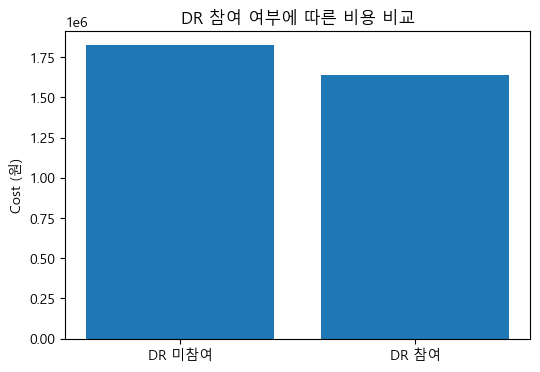

In [59]:
# =========================
# 비용 비교 그래프
# =========================

costs = [basic_charge_no_dr, basic_charge_with_dr - dr_revenue]

labels = ["DR 미참여", "DR 참여"]

plt.figure(figsize=(6,4))
plt.bar(labels, costs)

plt.title("DR 참여 여부에 따른 비용 비교")
plt.ylabel("Cost (원)")

plt.show()

In [60]:
# =========================
# DR 참여/미참여 생산량 비교
# =========================

# 피크 시간 행 찾기
peak_row = df_model.loc[df_model["datetime"] == peak_time].copy()

# 혹시 datetime exact match가 안 되면 idx 기준 사용
if len(peak_row) == 0:
    peak_idx = df_model["predicted_power"].idxmax()
    peak_row = df_model.loc[[peak_idx]].copy()

# 기준 생산량
production_before = float(peak_row["production"].iloc[0])

# DR 감축률
reduction_ratio = 0.10   # 예: 10%

# -------------------------
# 시나리오 A: 생산량 영향 없음
# -------------------------
production_after_case_a = production_before
production_loss_case_a = production_before - production_after_case_a

# -------------------------
# 시나리오 B: 생산량 일부 감소
# 생산영향계수 설정
# 예: 0.3 -> 전력 10% 감축 시 생산량은 3% 감소
# -------------------------
production_impact_ratio = 0.3

production_after_case_b = production_before * (1 - reduction_ratio * production_impact_ratio)
production_loss_case_b = production_before - production_after_case_b

# 비교표 생성
production_compare_df = pd.DataFrame({
    "구분": [
        "피크 시점 생산량",
        "DR 참여 후 생산량",
        "생산량 감소"
    ],
    "DR 미참여": [
        round(production_before, 2),
        round(production_before, 2),
        0
    ],
    "DR 참여(생산영향 없음)": [
        round(production_before, 2),
        round(production_after_case_a, 2),
        round(production_loss_case_a, 2)
    ],
    "DR 참여(생산영향 일부 반영)": [
        round(production_before, 2),
        round(production_after_case_b, 2),
        round(production_loss_case_b, 2)
    ]
})

print(production_compare_df)

            구분  DR 미참여  DR 참여(생산영향 없음)  DR 참여(생산영향 일부 반영)
0    피크 시점 생산량   805.0           805.0             805.00
1  DR 참여 후 생산량   805.0           805.0             780.85
2       생산량 감소     0.0             0.0              24.15


In [61]:
# =========================
# 생산량 감소에 따른 손실 비용
# =========================

profit_per_unit = 5000  # 생산 1단위당 이익(예시)

production_loss_cost_case_a = production_loss_case_a * profit_per_unit
production_loss_cost_case_b = production_loss_case_b * profit_per_unit

production_loss_df = pd.DataFrame({
    "시나리오": [
        "DR 참여(생산영향 없음)",
        "DR 참여(생산영향 일부 반영)"
    ],
    "생산량 감소": [
        round(production_loss_case_a, 2),
        round(production_loss_case_b, 2)
    ],
    "생산 손실 비용(원)": [
        round(production_loss_cost_case_a),
        round(production_loss_cost_case_b)
    ]
})

print(production_loss_df)

                시나리오  생산량 감소  생산 손실 비용(원)
0     DR 참여(생산영향 없음)    0.00            0
1  DR 참여(생산영향 일부 반영)   24.15       120750


In [62]:
# 기존 계산값이 있다고 가정
# dr_net_profit 또는 dr_profit 사용

real_profit_case_a = dr_profit - production_loss_cost_case_a
real_profit_case_b = dr_profit - production_loss_cost_case_b

profit_compare_df = pd.DataFrame({
    "시나리오": [
        "DR 참여(생산영향 없음)",
        "DR 참여(생산영향 일부 반영)"
    ],
    "기존 DR 순이익(원)": [
        round(dr_profit),
        round(dr_profit)
    ],
    "생산 손실 비용(원)": [
        round(production_loss_cost_case_a),
        round(production_loss_cost_case_b)
    ],
    "실제 순이익(원)": [
        round(real_profit_case_a),
        round(real_profit_case_b)
    ]
})

print(profit_compare_df)

                시나리오  기존 DR 순이익(원)  생산 손실 비용(원)  실제 순이익(원)
0     DR 참여(생산영향 없음)        184571            0     184571
1  DR 참여(생산영향 일부 반영)        184571       120750      63821


In [63]:
import pandas as pd

def get_alert_level(power, threshold):
    ratio = power / threshold

    if ratio < 0.80:
        return "정상"
    elif ratio < 0.90:
        return "관심"
    elif ratio < 0.95:
        return "주의"
    elif ratio < 1.00:
        return "경계"
    else:
        return "심각"


def add_peak_alert_5level(df, threshold):
    df = df.copy()

    df["alert_level"] = df["predicted_power"].apply(lambda x: get_alert_level(x, threshold))
    df["power_ratio"] = df["predicted_power"] / threshold

    return df

In [64]:
df_pred = pd.DataFrame({
    "datetime": pd.date_range("2021-08-01 00:00:00", periods=8, freq="H"),
    "predicted_power": [720, 830, 910, 945, 980, 1005, 1030, 870]
})

threshold = 1000

df_alert = add_peak_alert_5level(df_pred, threshold)
print(df_alert[["datetime", "predicted_power", "power_ratio", "alert_level"]])

             datetime  predicted_power  power_ratio alert_level
0 2021-08-01 00:00:00              720        0.720          정상
1 2021-08-01 01:00:00              830        0.830          관심
2 2021-08-01 02:00:00              910        0.910          주의
3 2021-08-01 03:00:00              945        0.945          주의
4 2021-08-01 04:00:00              980        0.980          경계
5 2021-08-01 05:00:00             1005        1.005          심각
6 2021-08-01 06:00:00             1030        1.030          심각
7 2021-08-01 07:00:00              870        0.870          관심


C:\Users\Admin\AppData\Local\Temp\ipykernel_11976\3038675274.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "datetime": pd.date_range("2021-08-01 00:00:00", periods=8, freq="H"),


In [65]:
def make_alert_message(row, threshold):
    level = row["alert_level"]
    power = row["predicted_power"]
    dt = row["datetime"]
    ratio = row["power_ratio"] * 100

    if level == "정상":
        return f"[정상] {dt} / 예측전력 {power:.1f}kW / 기준의 {ratio:.1f}%"
    elif level == "관심":
        return f"[관심] {dt} / 전력 사용량 증가 추세 / 기준의 {ratio:.1f}%"
    elif level == "주의":
        return f"[주의] {dt} / 피크 접근 중 / 기준의 {ratio:.1f}%"
    elif level == "경계":
        return f"[경계] {dt} / 피크 직전 단계 / 기준의 {ratio:.1f}%"
    else:
        return f"[심각] {dt} / 기준 초과 예상 / 즉시 대응 필요"
        

def add_alert_message(df, threshold):
    df = df.copy()
    df["alert_message"] = df.apply(lambda row: make_alert_message(row, threshold), axis=1)
    return df

In [66]:
def dr_recommendation(row, dr_reward_per_kwh, reduction_ratio, production_loss_cost):
    predicted_power = row["predicted_power"]
    alert_level = row["alert_level"]

    expected_reduction = predicted_power * reduction_ratio
    expected_reward = expected_reduction * dr_reward_per_kwh
    expected_profit = expected_reward - production_loss_cost

    if alert_level in ["경계", "심각"] and expected_profit > 0:
        recommendation = "DR 참여 추천"
    elif alert_level == "주의" and expected_profit > 0:
        recommendation = "DR 참여 검토"
    else:
        recommendation = "비참여"

    return pd.Series({
        "expected_reduction": expected_reduction,
        "expected_reward": expected_reward,
        "expected_profit": expected_profit,
        "dr_recommendation": recommendation
    })

In [67]:
def run_peak_alert_and_dr_5level(
    df,
    threshold,
    dr_reward_per_kwh=120,
    reduction_ratio=0.10,
    production_loss_cost=8000
):
    df = df.copy()

    df = add_peak_alert_5level(df, threshold)
    df = add_alert_message(df, threshold)

    dr_result = df.apply(
        lambda row: dr_recommendation(
            row,
            dr_reward_per_kwh=dr_reward_per_kwh,
            reduction_ratio=reduction_ratio,
            production_loss_cost=production_loss_cost
        ),
        axis=1
    )

    df = pd.concat([df, dr_result], axis=1)
    return df

In [68]:
import pandas as pd

# 1) 경보 단계 함수
def get_alert_level(power, threshold):
    ratio = power / threshold

    if ratio < 0.80:
        return "정상"
    elif ratio < 0.90:
        return "관심"
    elif ratio < 0.95:
        return "주의"
    elif ratio < 1.00:
        return "경계"
    else:
        return "심각"


# 2) 5단계 경보 부여
def add_peak_alert_5level(df, threshold):
    df = df.copy()
    df["power_ratio"] = df["predicted_power"] / threshold
    df["alert_level"] = df["predicted_power"].apply(lambda x: get_alert_level(x, threshold))
    return df


# 3) 경보 메시지 생성
def make_alert_message(row, threshold):
    level = row["alert_level"]
    power = row["predicted_power"]
    dt = row["datetime"]
    ratio = row["power_ratio"] * 100

    if level == "정상":
        return f"[정상] {dt} / 예측전력 {power:.1f}kW / 기준의 {ratio:.1f}%"
    elif level == "관심":
        return f"[관심] {dt} / 전력 사용량 증가 / 기준의 {ratio:.1f}%"
    elif level == "주의":
        return f"[주의] {dt} / 피크 접근 중 / 기준의 {ratio:.1f}%"
    elif level == "경계":
        return f"[경계] {dt} / 피크 직전 / 기준의 {ratio:.1f}%"
    else:
        return f"[심각] {dt} / 기준 초과 예상 / 즉시 대응 필요"


def add_alert_message(df, threshold):
    df = df.copy()
    df["alert_message"] = df.apply(lambda row: make_alert_message(row, threshold), axis=1)
    return df


# 4) DR 추천
def dr_recommendation(row, dr_reward_per_kwh, reduction_ratio, production_loss_cost):
    predicted_power = row["predicted_power"]
    alert_level = row["alert_level"]

    expected_reduction = predicted_power * reduction_ratio
    expected_reward = expected_reduction * dr_reward_per_kwh
    expected_profit = expected_reward - production_loss_cost

    if alert_level in ["경계", "심각"] and expected_profit > 0:
        recommendation = "DR 참여 추천"
    elif alert_level == "주의" and expected_profit > 0:
        recommendation = "DR 참여 검토"
    else:
        recommendation = "비참여"

    return pd.Series({
        "expected_reduction": expected_reduction,
        "expected_reward": expected_reward,
        "expected_profit": expected_profit,
        "dr_recommendation": recommendation
    })


# 5) 전체 실행 함수
def run_peak_alert_and_dr_5level(
    df,
    threshold,
    dr_reward_per_kwh=120,
    reduction_ratio=0.10,
    production_loss_cost=8000
):
    df = df.copy()

    df = add_peak_alert_5level(df, threshold)
    df = add_alert_message(df, threshold)

    dr_result = df.apply(
        lambda row: dr_recommendation(
            row,
            dr_reward_per_kwh=dr_reward_per_kwh,
            reduction_ratio=reduction_ratio,
            production_loss_cost=production_loss_cost
        ),
        axis=1
    )

    df = pd.concat([df, dr_result], axis=1)
    return df


# 6) 테스트용 데이터
df_test = pd.DataFrame({
    "datetime": pd.date_range("2021-08-01 10:00:00", periods=5, freq="H"),
    "predicted_power": [750, 850, 920, 970, 1010]
})

threshold = 1000

# 7) 실행
df_result = run_peak_alert_and_dr_5level(
    df_test,
    threshold=threshold,
    dr_reward_per_kwh=120,
    reduction_ratio=0.10,
    production_loss_cost=3000
)

# 8) 결과 확인
print(df_result[[
    "datetime",
    "predicted_power",
    "power_ratio",
    "alert_level",
    "alert_message",
    "expected_profit",
    "dr_recommendation"
]])

             datetime  predicted_power  power_ratio alert_level  \
0 2021-08-01 10:00:00              750         0.75          정상   
1 2021-08-01 11:00:00              850         0.85          관심   
2 2021-08-01 12:00:00              920         0.92          주의   
3 2021-08-01 13:00:00              970         0.97          경계   
4 2021-08-01 14:00:00             1010         1.01          심각   

                                       alert_message  expected_profit  \
0  [정상] 2021-08-01 10:00:00 / 예측전력 750.0kW / 기준의 ...           6000.0   
1   [관심] 2021-08-01 11:00:00 / 전력 사용량 증가 / 기준의 85.0%           7200.0   
2     [주의] 2021-08-01 12:00:00 / 피크 접근 중 / 기준의 92.0%           8040.0   
3       [경계] 2021-08-01 13:00:00 / 피크 직전 / 기준의 97.0%           8640.0   
4     [심각] 2021-08-01 14:00:00 / 기준 초과 예상 / 즉시 대응 필요           9120.0   

  dr_recommendation  
0               비참여  
1               비참여  
2          DR 참여 검토  
3          DR 참여 추천  
4          DR 참여 추천  


C:\Users\Admin\AppData\Local\Temp\ipykernel_11976\2748735992.py:105: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "datetime": pd.date_range("2021-08-01 10:00:00", periods=5, freq="H"),


In [69]:
expected_alerts = ["정상", "관심", "주의", "경계", "심각"]
actual_alerts = df_result["alert_level"].tolist()

assert actual_alerts == expected_alerts, f"경보 단계 오류! 실제 결과: {actual_alerts}"

print("경보 단계 테스트 통과")

경보 단계 테스트 통과


In [70]:
expected_recommendations = [
    "비참여",
    "비참여",
    "DR 참여 검토",
    "DR 참여 추천",
    "DR 참여 추천"
]

actual_recommendations = df_result["dr_recommendation"].tolist()

assert actual_recommendations == expected_recommendations, \
    f"DR 추천 오류! 실제 결과: {actual_recommendations}"

print("DR 추천 테스트 통과")

DR 추천 테스트 통과


In [71]:
df_boundary = pd.DataFrame({
    "datetime": pd.date_range("2021-08-01 00:00:00", periods=4, freq="H"),
    "predicted_power": [800, 900, 950, 1000]
})

df_boundary_result = run_peak_alert_and_dr_5level(
    df_boundary,
    threshold=1000,
    dr_reward_per_kwh=120,
    reduction_ratio=0.10,
    production_loss_cost=3000
)

print(df_boundary_result[["predicted_power", "power_ratio", "alert_level"]])

   predicted_power  power_ratio alert_level
0              800         0.80          관심
1              900         0.90          주의
2              950         0.95          경계
3             1000         1.00          심각


C:\Users\Admin\AppData\Local\Temp\ipykernel_11976\815158704.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "datetime": pd.date_range("2021-08-01 00:00:00", periods=4, freq="H"),


In [72]:
expected_boundary_alerts = ["관심", "주의", "경계", "심각"]
actual_boundary_alerts = df_boundary_result["alert_level"].tolist()

assert actual_boundary_alerts == expected_boundary_alerts, \
    f"경계값 테스트 오류! 실제 결과: {actual_boundary_alerts}"

print("경계값 테스트 통과")

경계값 테스트 통과


In [73]:
df_day_test = pd.DataFrame({
    "datetime": pd.date_range("2021-08-01 00:00:00", periods=24, freq="H"),
    "predicted_power": [
        700, 680, 690, 710, 730, 780,
        820, 860, 910, 940, 970, 990,
        1010, 1030, 980, 950, 920, 890,
        850, 830, 810, 790, 760, 740
    ]
})

df_day_result = run_peak_alert_and_dr_5level(
    df_day_test,
    threshold=1000,
    dr_reward_per_kwh=120,
    reduction_ratio=0.10,
    production_loss_cost=3000
)

print(df_day_result[["datetime", "predicted_power", "alert_level", "dr_recommendation"]])

              datetime  predicted_power alert_level dr_recommendation
0  2021-08-01 00:00:00              700          정상               비참여
1  2021-08-01 01:00:00              680          정상               비참여
2  2021-08-01 02:00:00              690          정상               비참여
3  2021-08-01 03:00:00              710          정상               비참여
4  2021-08-01 04:00:00              730          정상               비참여
5  2021-08-01 05:00:00              780          정상               비참여
6  2021-08-01 06:00:00              820          관심               비참여
7  2021-08-01 07:00:00              860          관심               비참여
8  2021-08-01 08:00:00              910          주의          DR 참여 검토
9  2021-08-01 09:00:00              940          주의          DR 참여 검토
10 2021-08-01 10:00:00              970          경계          DR 참여 추천
11 2021-08-01 11:00:00              990          경계          DR 참여 추천
12 2021-08-01 12:00:00             1010          심각          DR 참여 추천
13 2021-08-01 13:00:

C:\Users\Admin\AppData\Local\Temp\ipykernel_11976\1029282193.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  "datetime": pd.date_range("2021-08-01 00:00:00", periods=24, freq="H"),


공장 전력 데이터
+
기상 데이터
+
전국 전력 수요 데이터
+
공휴일 데이터
        ↓
데이터 전처리
(결측치 처리, 시간 정렬)
        ↓
데이터 병합 (Merge)
        ↓
Feature Engineering
        ↓
시계열 Feature 생성
        ↓
XGBoost 모델 학습
        ↓
전력 사용량 예측
        ↓
피크 위험 경보 시스템
        ↓
DR 감축 시뮬레이션
        ↓
전기요금 절감 계산
        ↓
DR 보상 계산
        ↓
생산 손실 비용 반영
        ↓
DR 경제성 분석
        ↓
알람 및 의사결정 추천

1. 목표
공장 전력 데이터를 활용하여 전력 사용량을 예측하고 전력 피크 위험을 사전에 탐지하며 DR(수요반응) 참여의 경제성을 판단하는 의사결정 지원 시스템을 구축하는 것을 목표로 한다.

2. 과정
공장 전력 데이터, 기상 데이터, 전국 전력 수요 데이터를 통합하여 전처리 및 Feature Engineering을 수행하였다.
XGBoost 모델을 이용해 전력 사용량을 예측하고 예측 전력을 기준으로 5단계 전력 피크 알람 시스템을 구축하였다.
피크 시간 전력 감축을 가정하여 전기요금 절감, DR 보상, 생산 손실 비용을 계산하고 DR 참여의 경제성을 판단하였다.

3. 결과
전력 예측을 통해 피크 위험을 사전에 탐지하고 경보를 발생시키는 시스템을 구현하였다.
또한 DR 참여 시 전기요금 절감과 보상을 고려한 경제성 분석을 수행하여 DR 참여 여부를 판단할 수 있는 모델을 구축하였다.

4. 활용
본 시스템은 전력 피크 알람 제공, DR 참여 추천, 전기요금 절감 전략 수립 등에 활용될 수 있으며 공장의 에너지 운영 의사결정을 지원하는 시스템으로 활용될 수 있다.

In [74]:
import streamlit as st
import pandas as pd

st.set_page_config(page_title="공장 전력 피크 관리 시스템", layout="wide")

# -----------------------------------
# 기본 데이터 생성
# -----------------------------------
time = pd.date_range("2021-08-01 00:00:00", periods=24, freq="H")

predicted_power = [
    700, 720, 730, 750, 780, 820,
    850, 880, 920, 950, 970, 990,
    1010, 1040, 1020, 980, 950, 930,
    900, 880, 860, 830, 800, 760
]

df = pd.DataFrame({
    "datetime": time,
    "predicted_power": predicted_power
})

df["hour"] = df["datetime"].dt.hour
df["date"] = df["datetime"].dt.date

# -----------------------------------
# 사이드바 메뉴
# -----------------------------------
st.sidebar.title("메뉴")
menu = st.sidebar.radio(
    "이동할 화면을 선택하세요",
    ["전력 예측", "피크 경보", "DR 경제성"]
)

st.sidebar.markdown("---")
st.sidebar.subheader("공통 설정")

threshold = st.sidebar.slider("피크 기준 전력(kW)", 800, 1200, 1000, 10)

reduction_ratio = st.sidebar.slider("감축 비율", 0.00, 0.30, 0.10, 0.01)
dr_price = st.sidebar.number_input("DR 단가(원/kWh)", min_value=0, value=120, step=10)
production_loss = st.sidebar.number_input("생산 손실 비용(원)", min_value=0, value=5000, step=1000)

# -----------------------------------
# 함수 정의
# -----------------------------------
def get_alert_level(power, threshold):
    ratio = power / threshold

    if ratio < 0.80:
        return "정상"
    elif ratio < 0.90:
        return "관심"
    elif ratio < 0.95:
        return "주의"
    elif ratio < 1.00:
        return "경계"
    else:
        return "심각"

def calculate_dr(row, reduction_ratio, dr_price, production_loss):
    power = row["predicted_power"]
    reduction = power * reduction_ratio

    # 예시용 시간대 요금
    if 0 <= row["hour"] < 9:
        tou_rate = 70
    elif 9 <= row["hour"] < 18:
        tou_rate = 110
    else:
        tou_rate = 150

    saving = reduction * tou_rate
    reward = reduction * dr_price
    profit = saving + reward - production_loss

    return pd.Series({
        "reduction": reduction,
        "tou_rate": tou_rate,
        "saving": saving,
        "reward": reward,
        "expected_profit": profit
    })

df["alert_level"] = df["predicted_power"].apply(lambda x: get_alert_level(x, threshold))

dr_result = df.apply(
    lambda row: calculate_dr(row, reduction_ratio, dr_price, production_loss),
    axis=1
)

df = pd.concat([df, dr_result], axis=1)

def recommend_dr(row):
    if row["alert_level"] in ["경계", "심각"] and row["expected_profit"] > 0:
        return "참여 추천"
    elif row["alert_level"] == "주의" and row["expected_profit"] > 0:
        return "참여 검토"
    else:
        return "비참여"

df["dr_recommendation"] = df.apply(recommend_dr, axis=1)

# -----------------------------------
# 공통 지표
# -----------------------------------
max_power = df["predicted_power"].max()
avg_power = df["predicted_power"].mean()
peak_time = df.loc[df["predicted_power"].idxmax(), "datetime"]
total_profit = df["expected_profit"].sum()

# -----------------------------------
# 1. 전력 예측 메뉴
# -----------------------------------
if menu == "전력 예측":
    st.title("전력 예측")

    col1, col2, col3 = st.columns(3)
    col1.metric("최대 예측 전력", f"{max_power:,.1f} kW")
    col2.metric("평균 예측 전력", f"{avg_power:,.1f} kW")
    col3.metric("피크 시간", str(peak_time))

    st.subheader("시간대별 예측 전력")
    st.line_chart(df.set_index("datetime")["predicted_power"])

    st.subheader("원본 데이터")
    show_count = st.slider("표시할 행 개수", 5, 24, 10)
    st.dataframe(df.head(show_count))

# -----------------------------------
# 2. 피크 경보 메뉴
# -----------------------------------
elif menu == "피크 경보":
    st.title("피크 경보")

    highest_order = {"정상": 0, "관심": 1, "주의": 2, "경계": 3, "심각": 4}
    current_max_alert = max(df["alert_level"], key=lambda x: highest_order[x])

    if current_max_alert == "심각":
        st.error("심각 : 기준 전력을 초과했습니다. 즉시 대응이 필요합니다.")
    elif current_max_alert == "경계":
        st.warning("경계 : 피크 직전 상태입니다. DR 참여를 검토하세요.")
    elif current_max_alert == "주의":
        st.warning("주의 : 전력 사용량이 빠르게 증가하고 있습니다.")
    elif current_max_alert == "관심":
        st.info("관심 : 전력 사용량을 모니터링하세요.")
    else:
        st.success("정상 : 현재 상태는 안정적입니다.")

    st.subheader("경보 단계 분포")
    alert_counts = df["alert_level"].value_counts().reindex(
        ["정상", "관심", "주의", "경계", "심각"], fill_value=0
    )
    st.bar_chart(alert_counts)

    st.subheader("경보 단계별 필터")
    selected_levels = st.multiselect(
        "보고 싶은 경보 단계를 선택하세요",
        ["정상", "관심", "주의", "경계", "심각"],
        default=["주의", "경계", "심각"]
    )

    filtered_alert = df[df["alert_level"].isin(selected_levels)]
    st.dataframe(filtered_alert[["datetime", "predicted_power", "alert_level"]])

# -----------------------------------
# 3. DR 경제성 메뉴
# -----------------------------------
elif menu == "DR 경제성":
    st.title("DR 경제성")

    col1, col2, col3 = st.columns(3)
    col1.metric("총 예상 절감액", f"{df['saving'].sum():,.0f} 원")
    col2.metric("총 DR 보상", f"{df['reward'].sum():,.0f} 원")
    col3.metric("총 예상 순이익", f"{total_profit:,.0f} 원")

    if total_profit > 0:
        st.success("경제성 판단 : DR 참여가 유리합니다.")
    else:
        st.error("경제성 판단 : DR 참여가 불리합니다.")

    st.subheader("시간대별 순이익")
    st.line_chart(df.set_index("datetime")["expected_profit"])

    st.subheader("DR 참여 추천 결과")
    rec_counts = df["dr_recommendation"].value_counts()
    st.bar_chart(rec_counts)

    selected_rec = st.selectbox(
        "추천 결과로 필터링",
        ["전체", "참여 추천", "참여 검토", "비참여"]
    )

    if selected_rec == "전체":
        result_df = df
    else:
        result_df = df[df["dr_recommendation"] == selected_rec]

    st.dataframe(
        result_df[
            [
                "datetime",
                "predicted_power",
                "alert_level",
                "saving",
                "reward",
                "expected_profit",
                "dr_recommendation"
            ]
        ]
    )

2026-03-17 17:33:20.588 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
C:\Users\Admin\AppData\Local\Temp\ipykernel_11976\1862033688.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time = pd.date_range("2021-08-01 00:00:00", periods=24, freq="H")
2026-03-17 17:33:20.594 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 17:33:20.690 
  command:

    streamlit run c:\Users\Admin\miniconda3\envs\power_peak_env\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-17 17:33:20.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 17:33:20.691 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when ru